# **Deep Learning and Neural Networks**
# **Week 8 Lab - Applications of Transformers**

This lab will explore generative AI as the main application of Transformer-based neural network architectures. This lab has two simple tasks:
- **Task 1**: Comparing discriminative vs generative approaches for a simple classification task with a real-world dataset. This task has two questions.
- **Task 2**: Using a small Vision-Language Model (VLM) for multimodal generation tasks (visual question answering). This task has three questions.

 **Important: Using a free GPU on Google Colab will help improve the speed of execution of all tasks in this lab (especially task 3, where you have to fine-tune a model!). To use a GPU on Google Colab, go to "Runtime", then select "Change runtime type", select one of the available GPUs under "Hardware accelerator" (e.g. T4 GPU) and click "Save".**

## **General Instructions**
1. Read the explanatory text and run each code chunk sequentially.
2. Questions for each task appear throughout the notebook. Add your answers by following the specific instructions. Some questions require coding, while others require analysis based on one or more code outputs.
3. After answering all questions, submit your notebook through the corresponding QMPlus link for this lab assignment.

First, let's import some required libraries and let's make some general configurations for our experiments.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
import requests
from PIL import Image
from transformers.image_utils import load_image

from sklearn.metrics import accuracy_score, precision_recall_fscore_support


# Enable HF transfer for faster dataset loading
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

We will also install some additional libraries, in case we do not have them installed already. These libraries will be helpful to speed-up execution of task 2.

In [2]:
#We may need to install two libraries to accelerate model load and inference
import importlib.util
import subprocess
import sys

package_name = "num2words"

if importlib.util.find_spec(package_name) is None:
    print("'num2words' not found. Installing now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    print("Installation complete.")
else:
    print("'num2words' is already installed.")

import num2words

package_name = "bitsandbytes"

if importlib.util.find_spec(package_name) is None:
    print("'bitsandbytes' not found. Installing now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    print("Installation complete.")
else:
    print("'bitsandbytes' is already installed.")

import bitsandbytes

'num2words' not found. Installing now...
Installation complete.
'bitsandbytes' not found. Installing now...
Installation complete.


## Task 1: Discriminative vs generative-supported approaches for a simple classification task

In this task, we compare two approaches to the same classification problem: a simple discriminative model based on logistic regression, and a fine-tuned version of a pre-trained language model.

We use the UCI Adult Income dataset, which contains demographic and employment information derived from the 1994 U.S. Census database. The goal is to predict whether an individual's annual income is above $50,000.

After loading the dataset from Hugging Face, we perform some pre-processing and extract a smaller subset of examples to make the experiments faster to run.

In [3]:
# Load dataset directly from Hugging Face (approx 32k rows)
dataset = load_dataset("jlh/uci-adult-income", split="train")
raw_df = pd.DataFrame(dataset)

#Pre-processing Filter out rows with missing/unknown values ('?') to keep things clean
raw_df = raw_df[(raw_df['workclass'] != '?') & (raw_df['education'] != '?')].reset_index(drop=True)

#Extract a balanced sample to make our experiments faster later on
high_income = raw_df[raw_df['income'] == 1].sample(250, random_state=42)
low_income = raw_df[raw_df['income'] == 0].sample(250, random_state=42)
df = pd.concat([high_income, low_income]).sample(frac=1, random_state=42).reset_index(drop=True)


README.md:   0%|          | 0.00/969 [00:00<?, ?B/s]

data/train-00000-of-00001-c690726d22d2e5(…): reconstructing file:   0%|          |  0.00B /  587kB            

data/train-00000-of-00001-c690726d22d2e5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/32561 [00:00<?, ? examples/s]

We will focus our modelling in a subset of features of our original dataset, and also partition the data into training and test. The same configuration will be used for both the discriminative and the fine-tuned versions of our solution.

In [4]:
# Build one shared split so tabular and text models evaluate on the same rows
feature_cols = ["age", "sex", "occupation", "workclass", "education"]
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42, stratify=df["income"])

To be able to use a pre-trained model which was trained on language, we will use a simple table-to-text approach to convert each example in our tabular dataset to a sequence of words.

In [5]:
#A function to convert tabular data into a text profile for each individual
def tabular_to_text(row):
    gender = "male" if row['sex'] == "Male" else "female" #Convert categorical gender to text
    text_sequence = f"A {row['age']} year old {gender} working as a {row['occupation'].lower()} in the {row['workclass'].lower()} sector with a {row['education']} degree."
    return text_sequence

df['text_profile'] = df.apply(tabular_to_text, axis=1) #Call the function to create a new column with text profiles
df['label'] = df['income']  #Keep the labels: 1 for income >50K, 0 for income <=50K

#Print a few examples to check the structure of our text representation of the census data
print("\n--- Example of Text Profiles and Labels ---")
print(df[['text_profile', 'income']].head(5).to_string(index=False))


--- Example of Text Profiles and Labels ---
                                                                                            text_profile  income
          A 30 year old female working as a  craft-repair in the  private sector with a  7th-8th degree.       0
        A 29 year old female working as a  tech-support in the  private sector with a  Assoc-voc degree.       1
A 41 year old female working as a  machine-op-inspct in the  private sector with a  Some-college degree.       0
     A 49 year old female working as a  prof-specialty in the  private sector with a  Assoc-acdm degree.       1
             A 37 year old female working as a  craft-repair in the  private sector with a  11th degree.       1


Now, we will extract the corresponding training and test sets, making sure that in both our discriminative and fine-tuned solutions have access to the same examples in each set.

In [6]:
#Train and test sets for the fine-tuned model
train_texts = df.loc[train_idx, "text_profile"].tolist()
test_texts = df.loc[test_idx, "text_profile"].tolist()

#Train and test sets for the discriminative/traditional model
X_train_tab_raw = df.loc[train_idx, feature_cols].reset_index(drop=True)
X_test_tab_raw = df.loc[test_idx, feature_cols].reset_index(drop=True)

#Labels
y_train = df.loc[train_idx, "label"].values
y_test = df.loc[test_idx, "label"].values

Our first approach will be to train a discriminative model using Logistic Regression. We will need to do some specific data preparation, including encoding categorical features into numbers using one-hot encoding, and normalising some of our numeric features.

In [7]:
#First, we will encode categorical features
categorical_cols = ["sex", "occupation", "workclass", "education"]
X_train_tab_df = pd.get_dummies(X_train_tab_raw, columns=categorical_cols, dtype=float) #Use one-hot encoding for categorical features
X_test_tab_df = pd.get_dummies(X_test_tab_raw, columns=categorical_cols, dtype=float) #Use one-hot encoding for categorical features
X_test_tab_df = X_test_tab_df.reindex(columns=X_train_tab_df.columns, fill_value=0.0)

#Convert to floating numbers for numerical stability in our simple logistic regression implementation
X_train_tab = X_train_tab_df.values.astype(np.float64)
X_test_tab = X_test_tab_df.values.astype(np.float64)

# Normalize age for stable gradient descent
age_idx = X_train_tab_df.columns.get_loc("age")
age_mean = X_train_tab[:, age_idx].mean()
age_std = X_train_tab[:, age_idx].std() + 1e-8
X_train_tab[:, age_idx] = (X_train_tab[:, age_idx] - age_mean) / age_std
X_test_tab[:, age_idx] = (X_test_tab[:, age_idx] - age_mean) / age_std


Next we will define a simple class that will be used to build our simple Logistic Regression model.

In [8]:
class SimpleLogisticRegression:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500))) #Apply the exponential function and clip the input to avoid overflow

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0.0

        for _ in range(self.epochs):
            linear_model = np.dot(X, self.weights) + self.bias #Linear model
            y_predicted = self._sigmoid(linear_model) #Apply sigmoid

            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y)) #Compute the gradient of the loss with respect to the weights
            db = (1 / num_samples) * np.sum(y_predicted - y) #Compute the gradient of the loss with respect to the bias

            self.weights -= self.lr * dw #Update the weights by moving in the opposite direction of the gradient scaled by the learning rate
            self.bias -= self.lr * db #Update the bias similarly

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias #Calculate the linear combination of inputs and weights, adding the bias term
        return self._sigmoid(linear_model) #Apply the sigmoid function to get probabilities

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int) #Return the predicted class labels

With our Simple Logistic Regression class defined, we can now train and evaluate the Logistic Regression model in our dataset.

In [9]:
#Train model using our implementation of logistic regression
lr_classifier = SimpleLogisticRegression(lr=0.5, epochs=10)
lr_classifier.fit(X_train_tab, y_train)

#Evaluate performance on the test set
y_pred_scratch = lr_classifier.predict(X_test_tab)
test_accuracy = np.mean(y_pred_scratch == y_test)
print(f" Logistic Regression Test Accuracy: {test_accuracy * 100:.2f}%")

 Logistic Regression Test Accuracy: 75.00%


Now, we will explore the alternative of using a GPT-2 pre-trained model and fine-tuning it for our classification task. The idea is that we can test whether the general knowledge stored in this pre-trained model would help our classification task in any way. We will use distilgpt2 as the pre-trained model - the model card can be found at: https://huggingface.co/distilbert/distilgpt2.

In the next cell, we load our model and tokenizer, and apply the tokenizer to our training and test sets.

In [10]:
clf_tokenizer = AutoTokenizer.from_pretrained("distilgpt2") #Use a tokenizer compatible with the DistilGPT2 model
clf_tokenizer.pad_token = clf_tokenizer.eos_token #Set the pad token to the end-of-sequence token for DistilGPT2

clf_model = AutoModelForSequenceClassification.from_pretrained("distilgpt2", num_labels=2) #Initialize the classification model with 2 labels
clf_model.config.pad_token_id = clf_tokenizer.eos_token_id #Set the pad token ID in the model configuration to match the tokenizer's pad token ID

# Tokenize text inputs for supervised classification
train_encodings = clf_tokenizer(train_texts, truncation=True, padding=True, max_length=128, return_tensors="pt") #Tokenize our input text data for the training set, with a max length of 128 tokens and return PyTorch tensors
test_encodings = clf_tokenizer(test_texts, truncation=True, padding=True, max_length=128, return_tensors="pt") #And do the same with the test set

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


We will need to arrange our dataset as an object with encoding and labels, so that it can be used by our model. We do this via a custom class ClassificationDataset.

In [11]:
class ClassificationDataset(Dataset): #Define a custom PyTorch Dataset class to handle our tokenized inputs and labels for the DistilGPT2 classifier
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx): #Define how to retrieve a single item from the dataset, including the input encodings and the corresponding label
        item = {key: val[idx] for key, val in self.encodings.items()} #Create a dictionary containing the input encodings for the specified index
        item["labels"] = self.labels[idx] #Add the corresponding label to the dictionary
        return item

train_dataset = ClassificationDataset(train_encodings, y_train) #Create an instance of the ClassificationDataset for the training set, passing in the tokenized encodings and the corresponding labels
test_dataset = ClassificationDataset(test_encodings, y_test) #Create an instance of the ClassificationDataset for the test set, passing in the tokenized encodings and the corresponding labels


And now we are ready to fine-tune our classifier on our training dataset. This process may take a few minutes.

In [12]:
clf_model.train() #Set the model to training mode, which enables features like dropout and batch normalization that are only used during training
clf_optimizer = torch.optim.AdamW(clf_model.parameters(), lr=2e-5) #Use Adam optimizer
num_clf_epochs = 3 #We will just run 3 epochs
clf_train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True) #Load the training dataset in batches of 16 examples

for epoch in range(num_clf_epochs):
    running_loss = 0.0

    for batch in tqdm(clf_train_loader, desc=f"Training DistilGPT2 classifier (epoch {epoch + 1}/{num_clf_epochs})"):
        clf_optimizer.zero_grad() #Reset the gradients of the model parameters to zero before computing the gradients for this batch
        outputs = clf_model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"], labels=batch["labels"]) #Compute the model outputs and loss for this batch, including the input IDs, attention masks, and labels. Attention mask is used to ignore padding tokens in the input sequences during loss computation.
        loss = outputs.loss #Extract the loss value from the model outputs

        loss.backward() #Compute the gradients of the loss with respect to the model parameters
        clf_optimizer.step() #Update the model parameters based on the computed gradients

        running_loss += loss.item() #Accumulate the loss for this batch to compute the average loss later

    avg_epoch_loss = running_loss / len(clf_train_loader) #Compute the average loss for this epoch by dividing the accumulated loss by the number of batches in the training loader
    print(f"Epoch {epoch + 1} average training loss: {avg_epoch_loss:.4f}")

print("Fine-tuning complete.")

Training DistilGPT2 classifier (epoch 1/3): 100%|██████████| 25/25 [01:35<00:00,  3.81s/it]


Epoch 1 average training loss: 1.3053


Training DistilGPT2 classifier (epoch 2/3): 100%|██████████| 25/25 [01:04<00:00,  2.57s/it]


Epoch 2 average training loss: 0.6971


Training DistilGPT2 classifier (epoch 3/3): 100%|██████████| 25/25 [01:12<00:00,  2.89s/it]

Epoch 3 average training loss: 0.6373
Fine-tuning complete.


**Task 1 - Question 1:** Summarise, in a few sentences, what the idea of the process of fine-tuning from a pre-trained generative model is.

Fine tuning starts from a generative model that has already been pre trained on a very large amount of general text, so it already carries a broad understanding of language before it sees our task. Instead of training a model from scratch, we take these pre trained weights and continue training them on our own smaller labelled dataset for the specific task, which in this lab is the set of income text profiles. During this continued training the weights are adjusted so that the general language knowledge is steered towards the specific classification problem we care about. By attaching a small classification head to distilgpt2 and train the whole model for a few epochs, so the model reuses its pre trained knowledge and only needs a modest amount of task data to specialise. The result is that we obtain a competitive classifier while relying on knowledge the model already acquired during pre training rather than learning everything from our small dataset alone.

Next, we will evalue our fine-tuned classifier on the test set, and compare its performance with our simple logistic regression classifier.

In [13]:
clf_model.eval() #Set the model to evaluation mode, which disables features like dropout and batch normalization that are only used during training
clf_test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False) #Load the test dataset in batches of 32 examples for evaluation
clf_preds = []

with torch.no_grad():
    for batch in tqdm(clf_test_loader, desc="Evaluating DistilGPT2 classifier"):
        outputs = clf_model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]) #Compute the model outputs for this batch, including the input IDs and attention masks. We don't provide labels here since we are only interested in predictions during evaluation.
        batch_preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy() #Get the predicted class labels for this batch by taking the index of the maximum logit value along the last dimension (dim=-1). This gives us the predicted class for each example in the batch. We then move the predictions to the CPU and convert them to a NumPy array for further processing.
        clf_preds.extend(batch_preds.tolist()) #Add the predicted class labels for this batch to the list of all predictions for the test set

#Calculate metrics on the DistilGPT2 fine-tuned classifier
clf_acc = accuracy_score(y_test, clf_preds)
clf_prec, clf_rec, clf_f1, _ = precision_recall_fscore_support(y_test, clf_preds, average="binary", zero_division=0)

#Calculate metrics on the simple logistic regression baseline
lr_acc = accuracy_score(y_test, y_pred_scratch)
lr_prec, lr_rec, lr_f1, _ = precision_recall_fscore_support(y_test, y_pred_scratch, average="binary", zero_division=0)

print(f"\n\n Simple Logistic Regression Classifier --> Accuracy: {lr_acc:.4f}, Precision: {lr_prec:.4f}, Recall: {lr_rec:.4f}, F1: {lr_f1:.4f}")
print(f"\n\n DistilGPT2 Fine-Tuned Classifier --> Accuracy: {clf_acc:.4f}, Precision: {clf_prec:.4f}, Recall: {clf_rec:.4f}, F1: {clf_f1:.4f}")

Evaluating DistilGPT2 classifier: 100%|██████████| 4/4 [00:04<00:00,  1.15s/it]



 Simple Logistic Regression Classifier --> Accuracy: 0.7500, Precision: 0.7551, Recall: 0.7400, F1: 0.7475


 DistilGPT2 Fine-Tuned Classifier --> Accuracy: 0.7700, Precision: 0.8140, Recall: 0.7000, F1: 0.7527


**Task 1 - Question 2:** As shown above, fine-tuning a pre-trained model for this income classification task achieves competitive performance compared to a simple logistic regression baseline, even with a small sample. Based on these results, please discuss (a) whether this result justifies the added complexity of fine-tuning for this specific problem, and (b) what key trade-offs—such as computational cost, latency, data constraints, and interpretability—you would consider in a real-world scenario when deciding between traditional machine learning techniques and pre-trained deep learning architectures.

For part (a), the results do not really justify the added complexity of fine tuning for this particular problem. The fine tuned distilgpt2 model reached an accuracy of 0.77 with an F1 of 0.7527, while the simple logistic regression baseline reached an accuracy of 0.75 with a very similar F1 of 0.7475. This is a very small improvement, and it came at the cost of downloading a pre trained model, converting the table into text, tokenising, and training over several epochs, which took far longer than fitting the logistic regression. For a small structured tabular problem like this, where the features are already clean and informative, the simple model captures almost all of the available signal, so the extra effort of fine tuning buys very little. Fine tuning would only start to look worthwhile if the dataset were much larger or if the input contained rich unstructured text that a linear model could not exploit.

For part (b), several trade offs matter when choosing between a traditional machine learning method and a pre trained deep learning model in a real setting. Computational cost is one, because the logistic regression trains in a fraction of a second on a CPU whereas fine tuning a transformer needs far more memory and ideally a GPU. Latency at inference time is another, since the linear model produces a prediction almost instantly while the transformer is much heavier to run, which matters when serving many requests or deploying on limited hardware. Data constraints also play a role, because traditional models work well on small clean tabular datasets, whereas the advantage of a pre trained model tends to appear when there is a large amount of data or unstructured text where its pre trained knowledge can be reused.

Interpretability is a further consideration, since the logistic regression exposes clear weights that show how each feature affects the prediction, which is valuable for a sensitive application like income prediction, while the transformer is essentially a black box. Taken together, the traditional model is preferable here, and the pre trained model becomes the better choice mainly when the data are large or unstructured and its extra cost and reduced transparency are justified by a clear gain in performance.

## Task 1: Using a small Vision-Language Model (VLMs) for multimodal tasks

In this task, we will explore visual question answering (VQA), a multimodal generative task where a model answers a textual question based on an accompanying image. Specifically, we will leverage SmolVLM, a highly efficient, small-scale Vision Language Model (VLM). For further context on the model's architecture and capabilities, you can refer to the official HuggingFace release blog (https://huggingface.co/blog/smolvlm), from which the following examples and benchmarks are adapted.

**This task requires a GPU, so please follow the instructions at the beginning of this Notebook to choose the T4 GPU in Google Colab as your runtime, if you haven't already.**

First, we will load the model. Please note that the following cell may take a few minutes to execute.

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

#We will setup a process called 4-bit quantization to save VRAM and speed up compute
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.float16) #Use 4-bit quantization to reduce memory usage and speed up inference on T4 GPUs. The quantization type is set to "nf4" (normal float 4), double quantization is enabled, and the compute data type is set to float16 for better performance on T4 GPUs.

#Load small VLM model SmolVLM
model_id = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)

#Our model is a multi-modal model that can take both text and images as input and generate text as output. We will use the processor to prepare the inputs for the model, including tokenizing the text and processing the images. The model is loaded with 4-bit quantization to save memory and speed up inference on T4 GPUs.
model = AutoModelForImageTextToText.from_pretrained(model_id, quantization_config=bnb_config, device_map="auto", _attn_implementation="sdpa") #device_map = auto automatically maps layers to the T4 GPU; _attn_implementation="sdpa" is a native PyTorch scaled dot-product attention (fastest on T4 GPU)


Using device: cuda


processor_config.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/430 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/3.64k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/63.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

**Task 2 - Question 1:** Read the description of SmolVLM at https://huggingface.co/blog/smolvlm. What types of tasks were used as part of the training data? Hint: Check the "Dataset" section.

According to the Dataset section of the SmolVLM blog, the model was trained mainly on two open datasets, The Cauldron and Docmatix, which together cover a range of multimodal task types. The strongest emphasis is on document understanding, which makes up around a quarter of the data, followed by image captioning. Alongside these, the mixture keeps balanced coverage of other capabilities including general visual question answering, visual reasoning, chart and table comprehension, optical character recognition or text transcription, and general instruction following. In other words, the training data was not a single task but a broad collection of vision and language tasks, which is why the model can describe images, answer questions about them, and read text from scanned documents as we see later in this lab.

Next, we will use the loaded model to generate an answer to a question about two images.

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



--- Answer: ---
 The first image shows a painting of two women in a room with a gold frame. The room has a white ceiling with intricate designs and a blue and white color scheme. The second image shows a painting of a woman in a room with a gold frame, a blue and white color scheme, and a white ceiling with intricate designs.

--- Input images ---


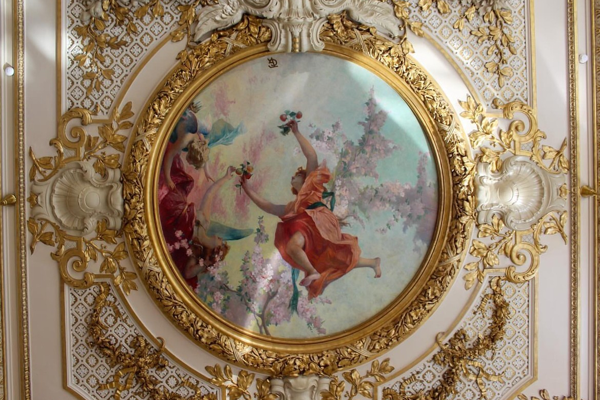

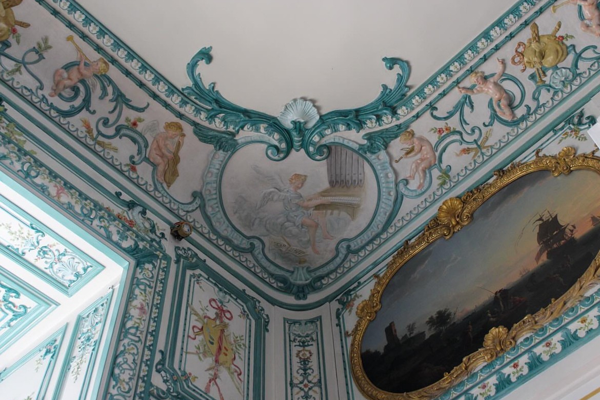

In [15]:
# Load images to generate captions on - in this example, we will use two input images
image1 = load_image("https://huggingface.co/spaces/HuggingFaceTB/SmolVLM/resolve/main/example_images/rococo.jpg")
image2 = load_image("https://huggingface.co/spaces/HuggingFaceTB/SmolVLM/resolve/main/example_images/rococo_1.jpg")

# Format standard chat prompt before passing instruction to the loaded VLM
question = "Describe the two images."
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"}, #append image 1 to the prompt
            {"type": "image"}, #append image 2 to the prompt
            {"type": "text", "text": question} #append the text question about these images
        ]
    }
]

prompt = processor.apply_chat_template(messages, add_generation_prompt=True) #Apply the chat template to the messages

inputs = processor(text=prompt, images=[image1, image2], return_tensors="pt").to(device) #Prepare the inputs for the model, including the prompt text and the two images. The inputs are returned as PyTorch tensors and moved to the appropriate device (GPU or CPU) for inference.

#Generate text output from the model based on the input images and prompt. We use torch.no_grad() to disable gradient calculations, which reduces memory usage and speeds up inference since we are not training the model.
with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=100)
    generated_text = processor.batch_decode(
        generated_ids[:, inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )

print("\n--- Answer: ---")
print(generated_text[0])

print("\n--- Input images ---")
small_image_display1 = image1.resize((600, 400))
small_image_display2 = image2.resize((600, 400))
display(small_image_display1)
print("\n")
display(small_image_display2)

**Task 2 - Question 2:** Observe the answer produced by the previous code cell. Is the answer output by the model reasonable? Why yes or why not?

The model correctly recognises that both inputs are paintings of women set in ornate interiors, and it picks up genuine visual details such as the gold frame, the light coloured ceiling with intricate decoration, and the blue and white colour scheme, which fit the Rococo style of the images. This shows that the model has grounded its description in what is actually present rather than inventing an unrelated scene. However, the answer is quite generic and repetitive, since the two descriptions are almost identical and it does not clearly bring out what is different between the two paintings.

This is expected behaviour for a small and heavily quantised Vision Language Model, which captures the overall gist of an image well but tends to produce vaguer and more templated descriptions than a larger model would. So the output is reasonable as a general caption, but it is limited in detail and accuracy.

VLMs can also be used to answer questions about documents that have been digitised, i.e. OCR (Optical Character Recognition) tasks. In the following code cell, we will query the model about a specific section of a scanned document.

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



--- Answer: ---
 The contact name in this document is John Smith.

--- Input digital document: ---


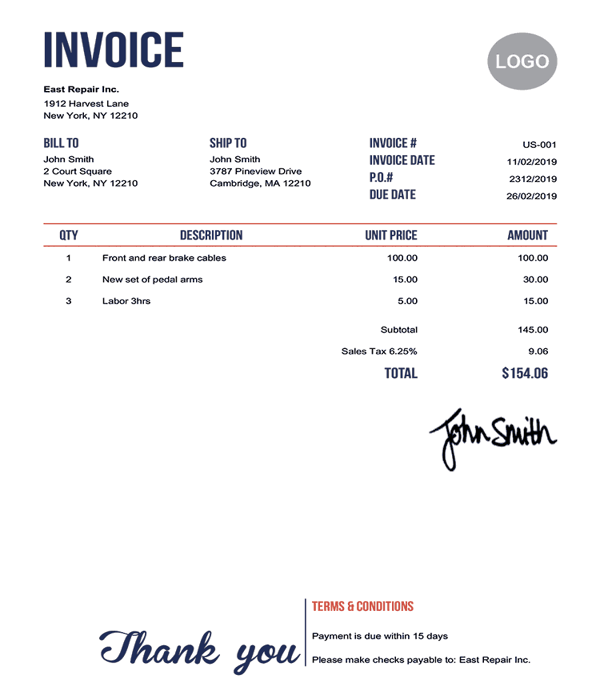

In [16]:
# The original document was served from a temporary gradio link that has since expired.
# We therefore load a stable, publicly hosted document image instead, using a small helper that verifies the download really is an image. This avoids the UnidentifiedImageError that happens when a URL returns an error page instead of image bytes.
import requests
from io import BytesIO
from PIL import Image

doc_url_primary = "https://templates.invoicehome.com/invoice-template-us-neat-750px.png"
doc_url_backup  = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/vlm_example.jpg"

def load_document_image(*urls):
    for url in urls:
        try:
            response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
            response.raise_for_status()
            if "image" in response.headers.get("Content-Type", ""):
                return Image.open(BytesIO(response.content)).convert("RGB")
            print(f"Skipping {url} because it did not return an image.")
        except Exception as error:
            print(f"Could not load {url}: {error}")
    raise RuntimeError("None of the candidate document URLs returned a valid image.")

# Actually load the document image (this is the line that creates ocr_image_obj)
ocr_image_obj = load_document_image(doc_url_primary, doc_url_backup)

# Format standard chat prompt before passing instruction to the loaded VLM
question = "What is the contact name in this document?"
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"}, #In this case, we only have one image as input
            {"type": "text", "text": question} #And our question is related again to something in that image
        ]
    }
]

prompt = processor.apply_chat_template(messages, add_generation_prompt=True)

inputs = processor(text=prompt, images=[ocr_image_obj], return_tensors="pt").to(device)

#Generate the answer
with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=100)
    generated_text = processor.batch_decode(
        generated_ids[:, inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )

print("\n--- Answer: ---")
print(generated_text[0])

print("\n--- Input digital document: ---")
small_image_display = ocr_image_obj.resize((600, 700))
display(small_image_display)

We can also ask questions about parts of the digitised document that follow a particular format, e.g. dates. This is exemplified in the following code cell.

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



--- Answer: ---
 The date in this document is 11/02/2019.

--- Input digital document: ---


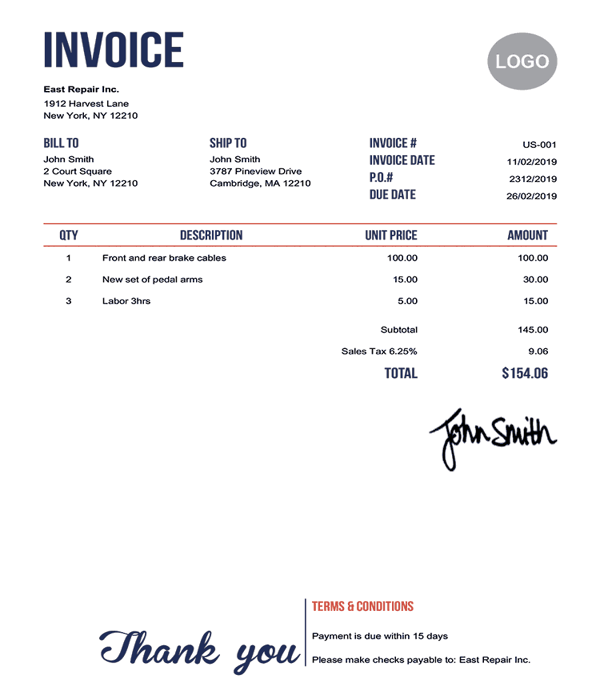

In [17]:
# Format standard chat prompt before passing instruction to the loaded VLM
question = "What is the date in this document?"
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": question} #Ask a different question about the same document image, in this case something that looks like a date
        ]
    }
]

prompt = processor.apply_chat_template(messages, add_generation_prompt=True)

inputs = processor(text=prompt, images=[ocr_image_obj], return_tensors="pt").to(device)

# Generate output
with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=100)
    generated_text = processor.batch_decode(
        generated_ids[:, inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )

print("\n--- Answer: ---")
print(generated_text[0])

print("\n--- Input digital document: ---")
small_image_display = ocr_image_obj.resize((600, 700))
display(small_image_display)

**Task 2 - Question 3:** Try changing the question text in the code cell above to "What is the proposed release date in this document?", and check the output text answer. Why do you think the model generates this output? Explain.

When the question is changed to ask specifically for the proposed release date, the model still returns a date taken from the document rather than saying that no such field exists. The reason is that the model is performing optical character recognition combined with a best guess at which piece of text is most relevant to the words in the question. It reads the date like text in the image and returns it, because a date is the most plausible answer to any question that contains the word date, but it does not truly verify whether that date is labelled as a proposed release date or as something else entirely. If the document happens to contain a field explicitly labelled as the proposed release date, the model may return it correctly by matching that label. If it does not, the model tends to fall back on the nearest date it can read and present it confidently, which is effectively a hallucination driven by pattern matching rather than a genuine understanding of the document structure. This illustrates a key limitation of using a small VLM for document question answering, namely that it grounds on surface cues and does not reliably reason about whether the text it finds actually answers the specific question that was asked.